In [1]:
import warnings
warnings.filterwarnings('ignore')
!pip install gensim pyLDAvis -q

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.utils import simple_preprocess

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 64.7 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
df = pd.read_csv('/content/drive/MyDrive/Final Project/reviews_clean.csv')
negative_df = df[df['rating'] <= 2].copy()
print(f"Total reviews: {len(df)}")
print(f"Negative reviews: {len(negative_df)}")

Total reviews: 11022
Negative reviews: 656


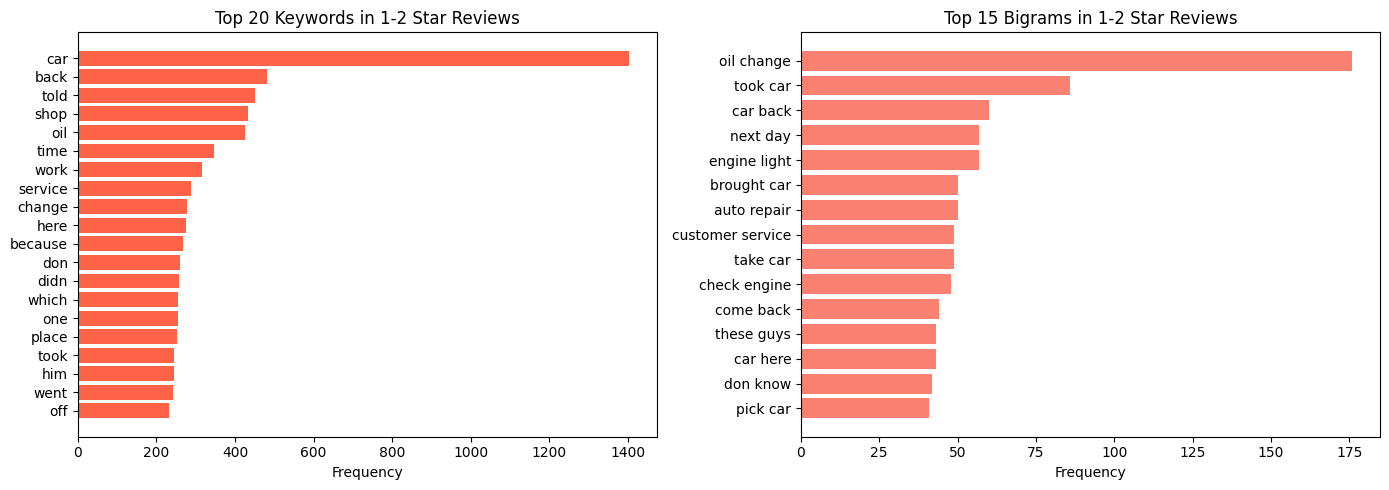

Top bigrams: [('oil change', 176), ('took car', 86), ('car back', 60), ('next day', 57), ('engine light', 57), ('brought car', 50), ('auto repair', 50), ('customer service', 49), ('take car', 49), ('check engine', 48)]


In [4]:
stop_words = set(['the','a','an','and','or','but','in','on','at','to','for',
                  'of','with','my','i','was','is','are','it','they','their',
                  'this','that','have','had','not','be','me','we','he','she',
                  'so','do','did','got','get','go','just','up','out','if','as',
                  'by','no','its','been','would','could','when','there','what',
                  'all','said','from','were','about','after','will','more','also',
                  'very','your','you','our','his','her','them','than','then','but'])

def tokenize(text):
    tokens = re.findall(r'\b[a-z]{3,}\b', str(text).lower())
    return [t for t in tokens if t not in stop_words]

def bigrams(text):
    tokens = tokenize(text)
    return [f"{tokens[i]} {tokens[i+1]}" for i in range(len(tokens)-1)]

all_tokens, all_bigrams_list = [], []
for text in negative_df['text']:
    all_tokens.extend(tokenize(text))
    all_bigrams_list.extend(bigrams(text))

top_words = Counter(all_tokens).most_common(20)
top_bigrams = Counter(all_bigrams_list).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
words, counts = zip(*top_words)
axes[0].barh(words[::-1], counts[::-1], color='tomato')
axes[0].set_title('Top 20 Keywords in 1-2 Star Reviews')
axes[0].set_xlabel('Frequency')

bigram_labels, bigram_counts = zip(*top_bigrams)
axes[1].barh(bigram_labels[::-1], bigram_counts[::-1], color='salmon')
axes[1].set_title('Top 15 Bigrams in 1-2 Star Reviews')
axes[1].set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Final Project/Visualizations/keywords.png', dpi=150)
plt.show()
print("Top bigrams:", top_bigrams[:10])

In [5]:
custom_stops = set(['car', 'shop', 'back', 'took', 'got', 'just', 'get',
                    'also', 'one', 'went', 'place', 'here', 'time', 'told',
                    'said', 'came', 'even', 'would', 'could', 'going',
                    'take', 'come', 'used', 'use', 'still', 'give',
                    'don', 'didn', 'doesn', 'wasn', 'won', 'can', 'two', 'him',
                    'because', 'which', 'them', 'they', 'their', 'there',
                    'was', 'that', 'this', 'with', 'but', 'not', 'have',
                    'had', 'when', 'after', 'were', 'been', 'has', 'are',
                    'what', 'you', 'your', 'will', 'from', 'about', 'out',
                    'more', 'than', 'then', 'its', 'into', 'who', 'how',
                    'our', 'said', 'his', 'her', 'she', 'the', 'and', 'for'])

def preprocess(text):
    tokens = simple_preprocess(str(text), deacc=True)
    return [t for t in tokens if t not in custom_stops and len(t) > 2]

texts = [preprocess(t) for t in negative_df['text']]
dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=5, no_above=0.7)
corpus = [dictionary.doc2bow(t) for t in texts]

lda_model = LdaModel(corpus=corpus, id2word=dictionary,
                     num_topics=4, passes=20, random_state=42)

for i, topic in lda_model.print_topics(num_words=12):
    print(f"\nTopic {i+1}: {topic}")


Topic 1: 0.012*"call" + 0.010*"did" + 0.010*"all" + 0.009*"repair" + 0.008*"never" + 0.008*"know" + 0.007*"day" + 0.007*"called" + 0.007*"issue" + 0.007*"tires" + 0.006*"very" + 0.006*"only"

Topic 2: 0.012*"service" + 0.010*"brake" + 0.010*"brakes" + 0.010*"work" + 0.009*"very" + 0.009*"front" + 0.008*"called" + 0.008*"needed" + 0.008*"done" + 0.007*"all" + 0.006*"new" + 0.006*"over"

Topic 3: 0.040*"oil" + 0.022*"change" + 0.015*"engine" + 0.009*"work" + 0.009*"check" + 0.009*"light" + 0.008*"service" + 0.008*"did" + 0.008*"filter" + 0.007*"air" + 0.007*"all" + 0.006*"off"

Topic 4: 0.008*"all" + 0.008*"parts" + 0.008*"labor" + 0.008*"did" + 0.007*"day" + 0.007*"like" + 0.007*"work" + 0.007*"job" + 0.006*"other" + 0.006*"quote" + 0.006*"repair" + 0.006*"off"


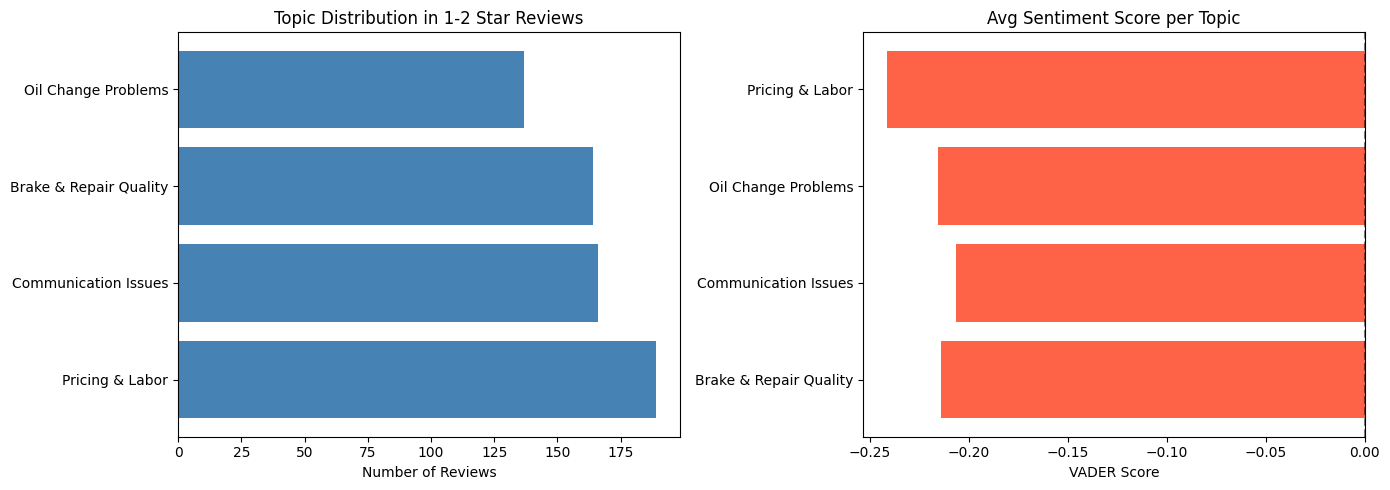


Topic counts:
 topic_label
Pricing & Labor           189
Communication Issues      166
Brake & Repair Quality    164
Oil Change Problems       137
Name: count, dtype: int64

Avg sentiment per topic:
 topic_label
Brake & Repair Quality   -0.214
Communication Issues     -0.206
Oil Change Problems      -0.215
Pricing & Labor          -0.242
Name: sentiment_score, dtype: float64

Final data saved to Drive!


In [7]:
topic_labels = {
    0: 'Communication Issues',
    1: 'Brake & Repair Quality',
    2: 'Oil Change Problems',
    3: 'Pricing & Labor'
}

def get_dominant_topic(bow):
    topics = lda_model.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0] if topics else -1

negative_df['dominant_topic'] = [get_dominant_topic(c) for c in corpus]
negative_df['topic_label'] = negative_df['dominant_topic'].map(topic_labels)

topic_counts = negative_df['topic_label'].value_counts()
topic_sentiment = negative_df.groupby('topic_label')['sentiment_score'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(topic_counts.index, topic_counts.values, color='steelblue')
axes[0].set_title('Topic Distribution in 1-2 Star Reviews')
axes[0].set_xlabel('Number of Reviews')

axes[1].barh(topic_sentiment.index, topic_sentiment.values, color='tomato')
axes[1].set_title('Avg Sentiment Score per Topic')
axes[1].set_xlabel('VADER Score')
axes[1].axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Final Project/Visualizations/lda_topics.png', dpi=150)
plt.show()

print("\nTopic counts:\n", topic_counts)
print("\nAvg sentiment per topic:\n", topic_sentiment.round(3))

# Save final DataFrame with topics
negative_df.to_csv('/content/drive/MyDrive/Final Project/negative_reviews_with_topics.csv', index=False)
print("\nFinal data saved to Drive!")